In [3]:
import json

with open('loss_history.json', 'r') as f:
    losses = json.load(f)

training_steps = [i for i, _, _ in losses]
train_loss = [train for _, train, _ in losses]
val_loss = [val for _, _, val in losses]

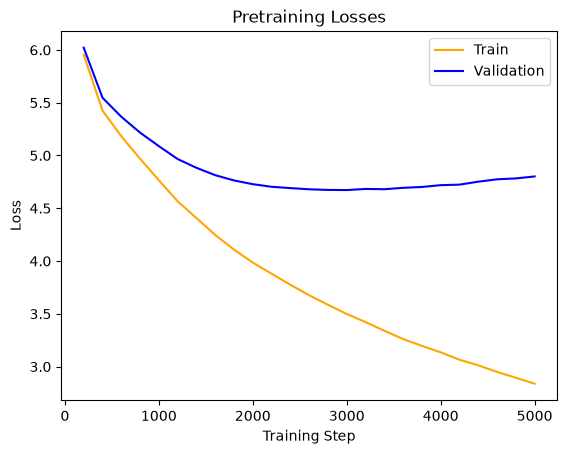

In [4]:
import matplotlib.pyplot as plt

plt.plot(training_steps, train_loss, c='orange', label='Train')
plt.plot(training_steps, val_loss, c='blue', label='Validation')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Pretraining Losses')
plt.legend()
plt.show()

In [12]:
import torch
from llm.model import LanguageModel
from llm.tokenizer import Tokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

pretrained = LanguageModel(device)
pretrained.load_state_dict(torch.load('pretrain_ckpt.pt', map_location=device)['model'])
finetuned_2000 = LanguageModel(device)
finetuned_2000.load_state_dict(torch.load('sft_ckpt_2000.pt', map_location=device)['model'])
finetuned_300 = LanguageModel(device)
finetuned_300.load_state_dict(torch.load('sft_ckpt_300.pt', map_location=device)['model'])

tok = Tokenizer()
tok.load('vocab.json')

In [14]:
prompt_text = 'This work presents a general framework for training'
formatted = f'<|prompt|>{prompt_text}<|response|>'
ids = tok.encode(formatted)

pretrained_out = pretrained.generate(torch.tensor([ids], dtype=torch.long, device=device), max_new_tokens=200, temp=0.7)
finetuned_2000_out = finetuned_2000.generate(torch.tensor([ids], dtype=torch.long, device=device), max_new_tokens=200, temp=0.7)
finetuned_300_out = finetuned_300.generate(torch.tensor([ids], dtype=torch.long, device=device), max_new_tokens=200, temp=0.7)

print(f'Pretrained Response: \n\n{tok.decode(pretrained_out[0].tolist())}\n\n')
print(f'Finetuned 2000 Example Response: \n\n{tok.decode(finetuned_2000_out[0].tolist())}\n\n')
print(f'Finetuned 300 Example Response: \n\n{tok.decode(finetuned_300_out[0].tolist())}')

Pretrained Response: 

<|prompt|>This work presents a general framework for training<|response|> distances. We integrate a representative and methodology that learns multiplayers to collect examples within 88 ones spanning 30 synthetic and real samples. The framework is evaluated against an optimal pipeline of 2,798 test cases, using only 17 synthetic samples, whose predicted radius peak training stability is evaluated across datasets, and all game binding. The results demonstrate that the largest gain comes from real and real data, and transcript-based approach achieves an area under the risk-averse demand model (AUROC).

Large language models (LLMs) have demonstrated strong performance across diverse domains (e.g., token generation, but their performance degraded in long-horizon domains remains unexplored. Existing federated learning methods are typically treated as a proxy for downstream task-based inference-time scalable, or learned modeling, while accounting over task-specific rep